## IMPORTS

In [3]:
!pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable


In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import numpy as np
import random
import tensorflow as tf
import seaborn as sns
import re

random.seed(58)
np.random.seed(58)
tf.random.set_seed(58)

## IMPORT DATASET

In [6]:
path = kagglehub.dataset_download("crowdflower/twitter-airline-sentiment")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\Jason Lee\.cache\kagglehub\datasets\crowdflower\twitter-airline-sentiment\versions\4


## LOAD DATASET

In [8]:
csv_path = os.path.join(path, "Tweets.csv")
df = pd.read_csv(csv_path)

print("Dataset shape:", df.shape)
print("Dataset columns:", df.columns)
print("First 5 rows of the dataset:")
print(df.head())

Dataset shape: (14640, 15)
Dataset columns: Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='object')
First 5 rows of the dataset:
             tweet_id airline_sentiment  airline_sentiment_confidence  \
0  570306133677760513           neutral                        1.0000   
1  570301130888122368          positive                        0.3486   
2  570301083672813571           neutral                        0.6837   
3  570301031407624196          negative                        1.0000   
4  570300817074462722          negative                        1.0000   

  negativereason  negativereason_confidence         airline  \
0            NaN                        NaN  Virgin America   
1            NaN                

## DATA EXPLORATION

#### Identify key columns

In [11]:
text_col = "text"
target_col = "airline_sentiment"

print("Text column:", text_col)
print("Target column:", target_col)

Text column: text
Target column: airline_sentiment


#### Check class distribution

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


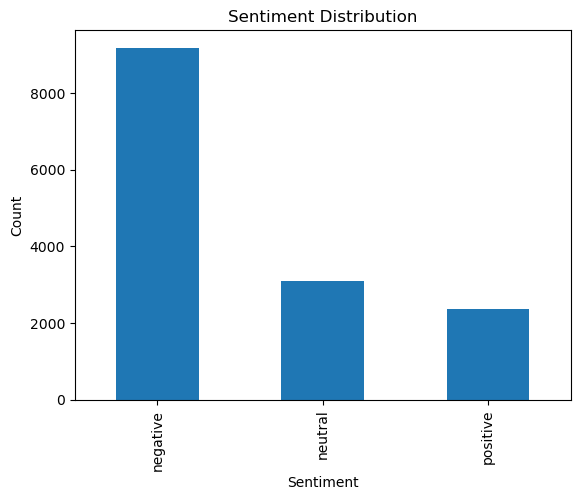

In [13]:
sentiment_counts = df[target_col].value_counts()

print(sentiment_counts)
sentiment_counts.plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

#### Check missing Values

In [15]:
df.isnull().sum()

tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64

#### Sample Tweets

In [17]:
df[text_col].sample(10).tolist()

['@USAirways 1 1/2 hours on hold to customer service without anyone answering is more than ridiculous!',
 '@SouthwestAir @Imaginedragons any info on #DestinationDragons ?? me &amp; @sammi_jon3s need to know..',
 '@united - 75% of a plane\'s passengers boarding in your "Premier" groups might be an indication of a broken process.',
 "@united so what's the solution?",
 "@AmericanAir \nNo one answers phone, delayed/Cancelled Flightled flights. Rude employees. You only get (I'm sorry, we apologize) blah blah blah. Bad",
 "@USAirways Cancelled Flightled flight, 50 person line and one agent helping to rebook. You could've handed this one better. http://t.co/By3vDioSUA",
 '@USAirways @AmericanAir Suggestions , been on hold 2 hrs for flight that is now about to pass departure...Dealing w ny weather, need change',
 '@SouthwestAir baggage delivery at BWI very delayed and unnecessarily chaotic. Disappointing after a long trip! From a frequent traveler',
 '@SouthwestAir Pres/CEO Gary Kelly at #TheR

## DATA PREPROCESSING

#### Keeping the Necessary Columns

In [20]:
tweets = df[[text_col, target_col]].copy()
tweets.head()

,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


#### Checking and removing duplicates

In [22]:
print("Before removing duplicates:", tweets.shape)

tweets = tweets.drop_duplicates()

print("After removing duplicates:", tweets.shape)

Before removing duplicates: (14640, 2)
After removing duplicates: (14452, 2)


#### Cleaning the tweet text

In [24]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

tweets["clean_text"] = tweets[text_col].apply(clean_text)

tweets[[text_col, "clean_text"]].head(10)

,text,clean_text
0,@VirginAmerica What @dhepburn said.,what said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercials to the experience...
2,@VirginAmerica I didn't today... Must mean I n...,i didnt today must mean i need to take another...
3,@VirginAmerica it's really aggressive to blast...,its really aggressive to blast obnoxious enter...
4,@VirginAmerica and it's a really big bad thing...,and its a really big bad thing about it
5,@VirginAmerica seriously would pay $30 a fligh...,seriously would pay a flight for seats that di...
6,"@VirginAmerica yes, nearly every time I fly VX...",yes nearly every time i fly vx this ear worm w...
7,@VirginAmerica Really missed a prime opportuni...,really missed a prime opportunity for men with...
8,"@virginamerica Well, I didn't…but NOW I DO! :-D",well i didntbut now i do d
9,"@VirginAmerica it was amazing, and arrived an ...",it was amazing and arrived an hour early youre...


#### Encoding sentiment labels

In [26]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
tweets["label"] = label_encoder.fit_transform(tweets[target_col])

print(label_encoder.classes_)
tweets[[target_col, "label"]].head()

['negative' 'neutral' 'positive']


,airline_sentiment,label
0,neutral,1
1,positive,2
2,neutral,1
3,negative,0
4,negative,0


#### Splitting into train and test

In [28]:
from sklearn.model_selection import train_test_split

X = tweets["clean_text"]
y = tweets["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=58,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (11561,)
X_test shape: (2891,)


## TRANSFORMER MODEL

#### Tokenize and pad the text with Keras

In [31]:
!pip install transformers

Defaulting to user installation because normal site-packages is not writeable


In [32]:
from transformers import AutoTokenizer

model_name = "distilbert-base-uncased"
max_len = 50

tokenizer = AutoTokenizer.from_pretrained(model_name)

train_encodings = tokenizer(
    list(X_train),
    truncation=True,
    padding=True,
    max_length=max_len,
    return_tensors="tf"
)

test_encodings = tokenizer(
    list(X_test),
    truncation=True,
    padding=True,
    max_length=max_len,
    return_tensors="tf"
)

print("train input_ids shape:", train_encodings["input_ids"].shape)
print("test input_ids shape:", test_encodings["input_ids"].shape)

train input_ids shape: (11561, 42)
test input_ids shape: (2891, 40)


#### Build the Transformer Model

In [34]:
from transformers import TFAutoModelForSequenceClassification

transformer_model = TFAutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_projector.bias', 'vocab_transform.weight', 'vocab_transform.bias', 'vocab_layer_norm.weight', 'vocab_layer_norm.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

#### Compiling the model

In [36]:
transformer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

## MODEL TRAINING

#### Train the Model

In [39]:
history = transformer_model.fit(
    {
        "input_ids": train_encodings["input_ids"],
        "attention_mask": train_encodings["attention_mask"]
    },
    y_train,
    validation_split=0.2,
    epochs=2,
    batch_size=16
)

Epoch 1/2


578/578 [==============================] - 385s 646ms/step - loss: 0.5292 - accuracy: 0.7911 - val_loss: 0.4396 - val_accuracy: 0.8249
Epoch 2/2
578/578 [==============================] - 401s 693ms/step - loss: 0.3274 - accuracy: 0.8805 - val_loss: 0.4613 - val_accuracy: 0.8236


## EVALUATION

#### Evaluating the model

In [42]:
test_loss, test_accuracy = transformer_model.evaluate(
    {
        "input_ids": test_encodings["input_ids"],
        "attention_mask": test_encodings["attention_mask"]
    },
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

91/91 [==============================] - 31s 323ms/step - loss: 0.4745 - accuracy: 0.8198
Test Loss: 0.4744631052017212
Test Accuracy: 0.8197855353355408


#### Making predictions

In [44]:
predictions = transformer_model.predict(
    {
        "input_ids": test_encodings["input_ids"],
        "attention_mask": test_encodings["attention_mask"]
    }
)

y_pred_classes = np.argmax(predictions.logits, axis=1)

91/91 [==============================] - 32s 333ms/step


#### Classification report

In [46]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_classes,
    target_names=label_encoder.classes_,
    zero_division=0
))

              precision    recall  f1-score   support

    negative       0.89      0.89      0.89      1818
     neutral       0.64      0.72      0.67       613
    positive       0.83      0.69      0.75       460

    accuracy                           0.82      2891
   macro avg       0.78      0.77      0.77      2891
weighted avg       0.82      0.82      0.82      2891



#### Confusion Matrix

[[1612  179   27]
 [ 133  440   40]
 [  70   72  318]]


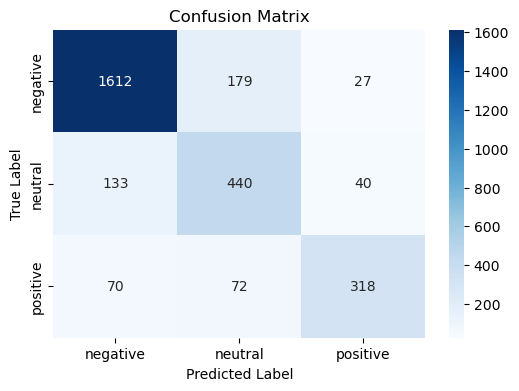

In [48]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_classes)
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

#### Plotting training graphs

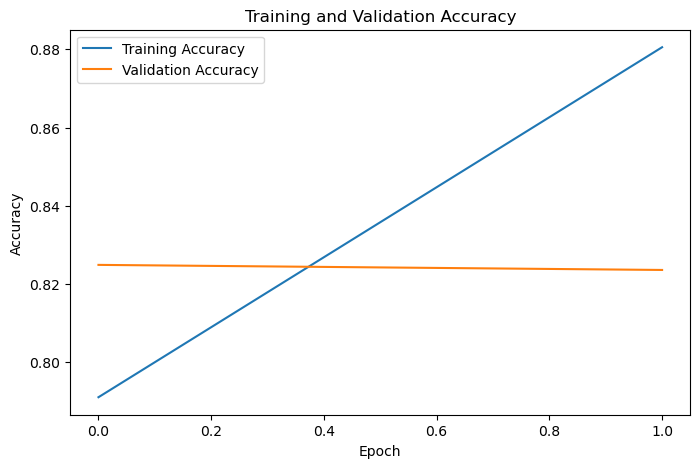

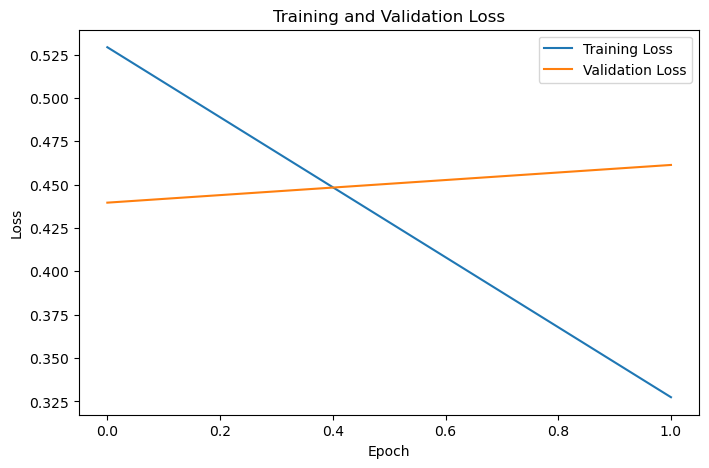

In [50]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()